In [339]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [340]:
words = open('names.txt', 'r').read().splitlines()

In [341]:
chars = sorted(set(''.join(words)))
stoi = {c: i+1 for i, c in enumerate(chars)}
stoi['.'] = 0
itos = {i: c for c, i in stoi.items()}

In [342]:
# create datasets

block_size = 3
X, Y = [], []

for name in words:
    context = [0] * block_size
    for ch in name + '.':
        X.append(context)
        Y.append(stoi[ch])
        context = context[1:] + [stoi[ch]]
X = torch.tensor(X)
Y = torch.tensor(Y)


In [343]:
# split to train, dev, test -datasets

n1 = int(0.8 * len(X))
n2 = int(0.9 * len(X))

Xtr, Ytr = X[:n1], Y[:n1]
Xdev, Ydev = X[n1:n2], Y[n1:n2]
Xtest, Ytest = X[n2:], Y[n2:]

In [344]:
print(Xtr.shape)
print(Xdev.shape)
print(Xtest.shape)

torch.Size([182516, 3])
torch.Size([22815, 3])
torch.Size([22815, 3])


In [387]:
g = torch.Generator().manual_seed(42)
vocab_size = len(stoi.keys()) # 27 chars
n_hidden = 100

# 10-dim embedding layer
C = torch.randn(vocab_size, 10, generator=g)

# first layer
W1 = torch.randn(30, n_hidden, generator=g)
b1 = torch.randn(n_hidden, generator=g)

# second layer
W2 = torch.randn(n_hidden, vocab_size, generator=g)
b2 = torch.randn(vocab_size, generator=g)

params = [C, W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

print('Num params: ', sum([p.nelement() for p in params]))

Num params:  6097


In [388]:
# training
batch_size=32
lossi = []

for i in range(50000):
    # forward pass

    # make batches
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    emb = C[Xtr[ix]].view(batch_size, -1)
    l1 = emb @ W1 + b1
    out1 = torch.tanh(l1)
    logits = out1 @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in params:
        p.grad = None
    loss.backward()

    for p in params:
        p.data += -.1 * p.grad if i < 25000 else -0.01 * p.grad
    lossi.append(loss.item())

In [389]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev': (Xdev, Ydev),
        'test': (Xtest, Ytest),
    }[split]
    emb = C[x].view(x.shape[0], -1)
    l1 = emb @ W1 + b1
    out = torch.tanh(l1)
    logits = out @ W2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('dev')


train 2.445751905441284
dev 2.664283037185669


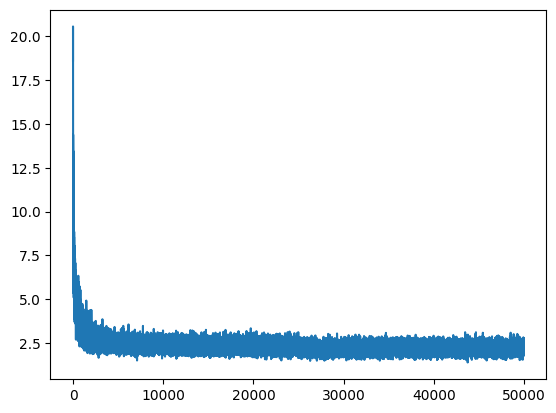

In [372]:
plt.plot(lossi)

In [373]:
# sample from the model
names = []
temp = []

for i in range(10):
    out = []
    context = [0] * block_size
    while True:
        with torch.no_grad():
            emb = C[context].view(-1)
            l1 = emb @ W1 + b1
            h1 = torch.tanh(l1)
            logits = h1 @ W2 + b2
            probs = torch.softmax(logits, dim=-1)
            pred = torch.multinomial(probs, 1, replacement=True).item()
            if pred == 0:
                print(''.join(out))
                break
            context = context[1:] + [pred]
            out.append(itos[pred])    

noce
arenge
sas
aziah
zemmriel
bron
aunetireh
samorra
lathora
eveatilingti


In [374]:
g = torch.Generator().manual_seed(42)
vocab_size = len(stoi.keys()) # 27 chars
n_emb = 10
n_hidden = 100

# 10-dim embedding layer
C = torch.randn(vocab_size, 10, generator=g)

# first layer
W1 = torch.randn(30, n_hidden, generator=g) * (5/3) / (vocab_size*n_emb)**0.5
#b1 = torch.randn(n_hidden, generator=g) * 0.1

# batchnorm paramaters
bngain = torch.ones(1, n_hidden)
bnbias = torch.zeros(1, n_hidden)

# second layer
W2 = torch.randn(n_hidden, vocab_size, generator=g)
b2 = torch.randn(vocab_size, generator=g)

params = [C, W1, W2, b2, bnbias, bngain]
for p in params:
    p.requires_grad = True

print('Num params: ', sum([p.nelement() for p in params]))

Num params:  6197


In [375]:
torch.nn.init.calculate_gain('tanh')

1.6666666666666667

In [376]:
# training
batch_size=32
lossi = []

for i in range(50000):
    # forward pass

    # make batches
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    emb = C[Xtr[ix]].view(batch_size, -1)
    l1 = emb @ W1
    l1mean = l1.mean(0, keepdim=True)
    l1std = l1.std(0, keepdim=True)
    x_hat = bngain * (l1 - l1mean) / l1std + bnbias
    out1 = torch.tanh(x_hat)
    logits = out1 @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in params:
        p.grad = None
    loss.backward()

    # update values
    for p in params:
        p.data += -.1 * p.grad if i < 25000 else -0.01 * p.grad
    lossi.append(loss.item())

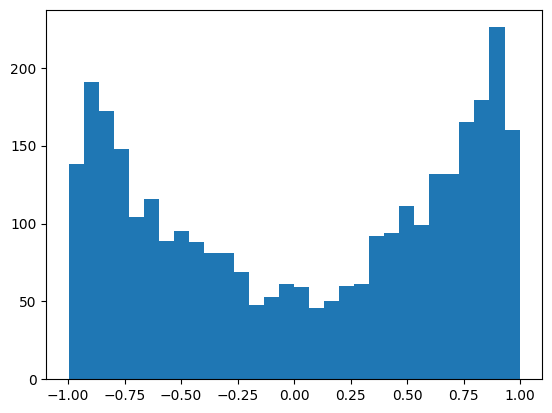

In [377]:
# check out the first non-linear layer output
plt.hist(out1.view(-1).tolist(), bins=30);

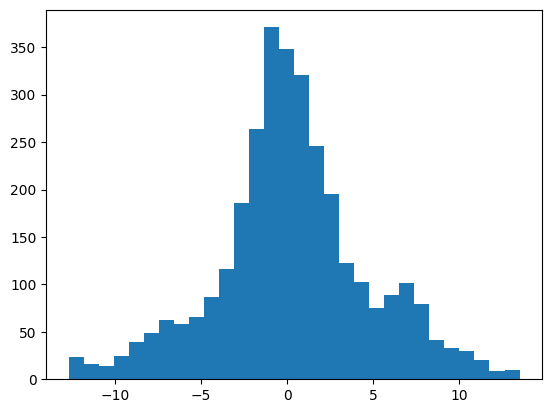

In [378]:
# the culprit is the first linear layer and its too large outputs for tanh
# multiplying the W1 layer with the recommended gain narrows the distribution
plt.hist(l1.view(-1).tolist(), bins=30);

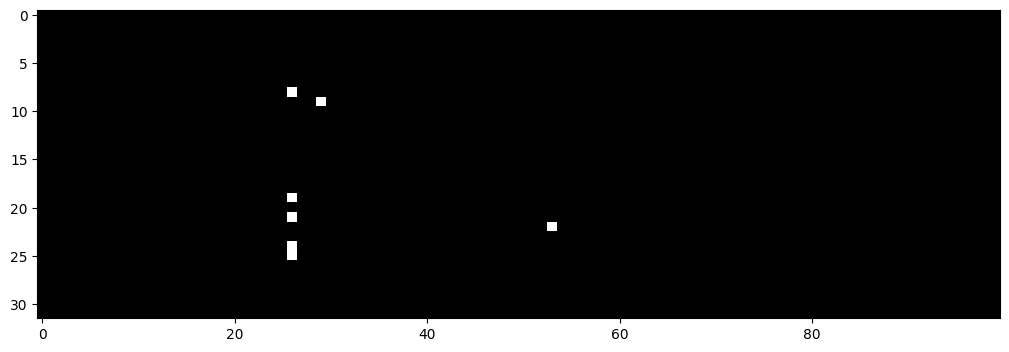

In [379]:
# this shows how many of the neurons are effectively on the outer edges of the tanh values

plt.figure(figsize=(20,4))
plt.imshow(out1.abs() > 0.99, cmap='gray', interpolation='nearest');

In [380]:
# calibrate the std and mean over the whole dataset if not done in running training
with torch.no_grad():
    emb = C[Xtr].view(Xtr.shape[0], -1)
    h1 = emb @ W1
    h1mean = h1.mean(0, keepdim=True)
    h1std = h1.std(0, keepdim=True)

In [381]:
# sample from the model
names = []
temp = []

for i in range(10):
    out = []
    context = [0] * block_size
    while True:
        with torch.no_grad():
            emb = C[context].view(1, -1)
            l1 = emb @ W1

            l1preact = bngain * (l1 - h1mean) / h1std + bnbias

            h1 = torch.tanh(l1preact)
            logits = h1 @ W2 + b2
            probs = torch.softmax(logits, dim=-1)
            pred = torch.multinomial(probs, 1, replacement=True).item()
            if pred == 0:
                print(''.join(out))
                break
            context = context[1:] + [pred]
            out.append(itos[pred])    

merptyn
gastinte
chelvika
faillasiadyah
alabrocen
brivi
tia
amila
anley
kyan


In [385]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev': (Xdev, Ydev),
        'test': (Xtest, Ytest),
    }[split]
    emb = C[x].view(x.shape[0], -1)
    l1 = emb @ W1
    l1preact = bngain * (l1 - h1mean) / h1std + bnbias
    out = torch.tanh(l1preact)
    logits = out @ W2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('dev')


train 2.4539005756378174
dev 2.7079763412475586
